In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
%load_ext rpy2.ipython

## Install R libraries

In [ ]:
%%R 

install.packages('Hmisc',depencies=TRUE,quiet=TRUE)
install.packages('patchwork',quiet=TRUE)
install.packages('gghalves',quiet=TRUE)
install.packages('here',quiet=TRUE)

install.packages("tidymodels",quiet=TRUE)
install.packages('tidytext',quiet=TRUE)
install.packages('plotly',quiet=TRUE)
install.packages('ggpubr',quiet=TRUE)
install.packages('GGally',quiet=TRUE)
install.packages('ggdist',quiet=TRUE)
install.packages('embed',quiet=TRUE)

In [2]:
%%R

library(Hmisc)
library(here)
library(patchwork)
library(gghalves)
library(tidyverse)
library(tidymodels)
library(tidytext)
library(plotly)
library(ggpubr)
library(GGally)
library(ggdist)
library(embed)
library(here)
library(fs)

R[write to console]: Loading required package: lattice

R[write to console]: Loading required package: survival

R[write to console]: Loading required package: Formula

R[write to console]: Loading required package: ggplot2

R[write to console]: 
Attaching package: ‘Hmisc’


R[write to console]: The following objects are masked from ‘package:base’:

    format.pval, units


R[write to console]: here() starts at /run/media/charly/MPB_DATA/Projects

R[write to console]: ── Attaching packages ─────────────────────────────────────── tidyverse 1.3.1 ──

R[write to console]: ✔ tibble  3.1.7     ✔ dplyr   1.0.9
✔ tidyr   1.2.0     ✔ stringr 1.4.0
✔ readr   2.1.2     ✔ forcats 0.5.1
✔ purrr   0.3.4     

R[write to console]: ── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter()    masks stats::filter()
✖ dplyr::lag()       masks stats::lag()
✖ dplyr::src()       masks Hmisc::src()
✖ dplyr::summarize() masks Hmisc::summarize()

R[write to console]: ─

## Setup directories

In [3]:
rootDir="/content/drive/MyDrive/SYNC_Projects/"
rootDir="/home/charly/Lab/Projects/SYNC_Projects/"

rootDir=rootDir+"pBGT/ms/"
workingDir=rootDir+"code/Supplementary/"

data_path=rootDir+"data/uJ_data/"
fig_path=rootDir+"figures/SuppFigures/"
print(data_path)

%Rpush data_path
%Rpush fig_path


/home/charly/Lab/Projects/SYNC_Projects/pBGT/ms/data/uJ_data/


## Loading data

In [5]:
%%R

#lineages_file <- here("data", "processed", "lineages.csv")
lineages_file <- paste(data_path, "processed_lineages.csv",sep="")

lineages_raw_df <- read_csv(
  file = lineages_file,
  show_col_types = FALSE
) %>%
  glimpse()

print(head(lineages_raw_df,2))
print(tail(lineages_raw_df,2))

Rows: 98,768
Columns: 21
$ experiment_id                 <chr> "Chromosome", "Chromosome", "Chromosome"…
$ id                            <chr> "xy01_1_10.008-34.000", "xy01_1_10.008-3…
$ division                      <lgl> FALSE, TRUE, FALSE, FALSE, FALSE, FALSE,…
$ filamented_at_time            <lgl> FALSE, TRUE, FALSE, FALSE, FALSE, FALSE,…
$ over_ds_red_threshold_at_time <lgl> FALSE, FALSE, FALSE, FALSE, FALSE, FALSE…
$ filamented_id                 <lgl> TRUE, TRUE, TRUE, TRUE, TRUE, TRUE, TRUE…
$ survived                      <lgl> TRUE, TRUE, TRUE, TRUE, TRUE, TRUE, TRUE…
$ length                        <dbl> 25.84965, 41.41517, 19.34801, 26.30153, …
$ gfp                           <dbl> 0.9840791, 0.9855457, 0.9812525, 0.98130…
$ ds_red                        <dbl> 0.0061646271, 0.0064229106, 0.0021434156…
$ antibiotic_start_time         <dbl> 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, …
$ antibiotic_end_time           <dbl> 100, 100, 100, 100, 100, 100, 100, 100, …
$ time         

In [32]:
%%R
lineages_processed_1_df <- lineages_raw_df %>%
  mutate(
    filamented_id = factor( x = filamented_id,levels = c(FALSE, TRUE),labels = c("Not filamented", "Filamented")),
    filamented_at_time = factor(x = filamented_at_time,levels = c(FALSE, TRUE),labels = c("Not filamented", "Filamented")),
    survived = factor(x = survived,levels = c(FALSE, TRUE),labels = c("Not survived", "Survived")),
    cell_status = interaction(filamented_id,survived,sep = " - ") 
    %>% as.character() %>% as.factor()) %>%
glimpse()

Rows: 98,768
Columns: 22
$ experiment_id                 <chr> "Chromosome", "Chromosome", "Chromosome"…
$ id                            <chr> "xy01_1_10.008-34.000", "xy01_1_10.008-3…
$ division                      <lgl> FALSE, TRUE, FALSE, FALSE, FALSE, FALSE,…
$ filamented_at_time            <fct> Not filamented, Filamented, Not filament…
$ over_ds_red_threshold_at_time <lgl> FALSE, FALSE, FALSE, FALSE, FALSE, FALSE…
$ filamented_id                 <fct> Filamented, Filamented, Filamented, Fila…
$ survived                      <fct> Survived, Survived, Survived, Survived, …
$ length                        <dbl> 25.84965, 41.41517, 19.34801, 26.30153, …
$ gfp                           <dbl> 0.9840791, 0.9855457, 0.9812525, 0.98130…
$ ds_red                        <dbl> 0.0061646271, 0.0064229106, 0.0021434156…
$ antibiotic_start_time         <dbl> 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, …
$ antibiotic_end_time           <dbl> 100, 100, 100, 100, 100, 100, 100, 100, …
$ time         

In [ ]:
%%R
theme_set(theme_bw() +theme(legend.position = "top",strip.background = element_blank()))

In [ ]:
%%R
status_time_df <- lineages_processed_1_df %>%
  select(experiment_id, id, time) %>%
  group_by(experiment_id) %>%
  group_modify(~ complete(expand(.x, id, time))) %>%
  ungroup() %>%
  left_join(lineages_processed_1_df) %>%
  rename(cell_status_at_time = filamented_at_time) %>%
  fill(time_first, time_last, gfp_first, filamentation_threshold, ds_red_threshold, .direction = "up") %>%
  fill(antibiotic_start_time, antibiotic_end_time, .direction = "down") %>%
  filter(time >= time_first) %>%
  mutate(
    cell_status_at_time = as.character(cell_status_at_time),
    cell_status_at_time = replace_na(cell_status_at_time, "Dead"),
    cell_status_at_time = factor(
      x = cell_status_at_time,
      levels = c("Not filamented", "Filamented", "Dead")
    ),
    time = factor(time)
  ) %>%
  glimpse() %>%
  identity()

Joining, by = c("experiment_id", "id", "time")
Rows: 166,866
Columns: 22
$ experiment_id                 <chr> "Chromosome", "Chromosome", "Chromosome"…
$ id                            <chr> "xy01_1_10.008-34.000", "xy01_1_10.008-3…
$ time                          <fct> 0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 1…
$ division                      <lgl> FALSE, TRUE, FALSE, FALSE, FALSE, FALSE,…
$ cell_status_at_time           <fct> Not filamented, Filamented, Not filament…
$ over_ds_red_threshold_at_time <lgl> FALSE, FALSE, FALSE, FALSE, FALSE, FALSE…
$ filamented_id                 <fct> Filamented, Filamented, Filamented, Fila…
$ survived                      <fct> Survived, Survived, Survived, Survived, …
$ length                        <dbl> 25.84965, 41.41517, 19.34801, 26.30153, …
$ gfp                           <dbl> 0.9840791, 0.9855457, 0.9812525, 0.98130…
$ ds_red                        <dbl> 0.0061646271, 0.0064229106, 0.0021434156…
$ antibiotic_start_time         <dbl> 60, 60, 6

### pop lvl

In [25]:
%%R
data_dir <- here(data_path)

cells_file <- paste(data_path, "cells_summary.csv",sep="")
cells_raw_df <- read_csv(
  file = cells_file,
  show_col_types = FALSE
) %>% 
  select(-over_ds_red_id) %>%
  rename(divided = divided_id)

print(head(cells_raw_df,2))
tail(cells_raw_df,n=c(2))

# A tibble: 2 × 25
  experiment_id id               divided_once_ex… filamented_id divided survived
  <chr>         <chr>            <lgl>            <lgl>         <lgl>   <lgl>   
1 Chromosome    xy01_1_10.008-3… TRUE             TRUE          TRUE    TRUE    
2 Chromosome    xy01_1_11.006-2… FALSE            TRUE          TRUE    TRUE    
# … with 19 more variables: antibiotic_start_time <dbl>,
#   antibiotic_end_time <dbl>, filamentation_threshold <dbl>, time_first <dbl>,
#   time_sos <dbl>, time_last <dbl>, length_first <dbl>, length_sos <dbl>,
#   length_last <dbl>, gfp_first <dbl>, gfp_sos <dbl>, gfp_last <dbl>,
#   ds_red_first <dbl>, ds_red_sos <dbl>, ds_red_last <dbl>, n_divisions <dbl>,
#   time_since_last_division_to_experiment_start <dbl>, lived_time <dbl>,
#   dead_or_missing_at_time <dbl>
# A tibble: 2 × 25
  experiment_id id               divided_once_ex… filamented_id divided survived
  <chr>         <chr>            <lgl>            <lgl>         <lgl>   <lgl>   
1 Pla

In [26]:
%%R
cells_df <- cells_raw_df %>% 
  mutate(
    filamented_id = factor(x = filamented_id,levels = c(FALSE, TRUE), labels = c("Not filamented", "Filamented")),
    survived = factor(x = survived,levels = c(FALSE, TRUE),labels = c("Not survived", "Survived")),
    cell_status = interaction(filamented_id,survived,sep = " - "),
    cell_status = paste0(filamented_id," - ",survived),
    cell_status = factor(cell_status)) %>% 
  relocate(where(is.character), where(is.factor), where(is.logical))

### addictional functions

In [27]:
%%R
parse_metrics_column <- function(.data, metric_column) {
  .data %>% 
    mutate(
      {{ metric_column }} := str_remove(
        string = {{ metric_column }},
        pattern = "(.+)_"
      ) %>% 
        factor(
          levels = c("first", "sos", "last"),
          labels = c("Initial", "SOS", "End")
        ) %>%
        identity()
    )
}

## Plotting Fig S4

[1] "/home/charly/Lab/Projects/SYNC_Projects/pBGT/ms/figures/SuppFigures/sFig-4.pdf"


R[write to console]: Saving 6.67 x 6.67 in image

R[write to console]: `geom_smooth()` using formula 'y ~ x'

R[write to console]: `geom_smooth()` using formula 'y ~ x'



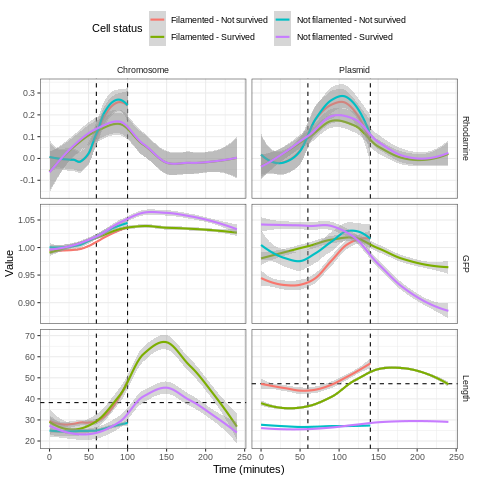

In [ ]:
%%R
p_metrics_over_time <- lineages_processed_1_df %>%
  select(experiment_id, cell_status, time, length, gfp, ds_red) %>%
  pivot_longer(
    cols = c(length, gfp, ds_red),
    names_to = "metric"
  ) %>%
  mutate(
    metric = case_when(
      metric == "ds_red" ~ "Rhodamine",
      metric == "gfp" ~ "GFP",
      metric == "length" ~ "Length"
    ),
    filamentation_threshold = ifelse(metric == "length", filamentation_threshold, NA)
  ) %>%
  group_by(experiment_id, cell_status, time, metric) %>%
  summarise(
    ci = list(mean_cl_normal(value)),
    .groups = "drop"
  ) %>%
  unnest(cols = c(ci)) %>%
  left_join(
    y = lineages_processed_1_df %>%
      select(experiment_id, antibiotic_start_time, antibiotic_end_time, filamentation_threshold) %>%
      distinct(),
    by = c("experiment_id")
  ) %>%
  mutate(
    filamentation_threshold = ifelse(metric == "Length", filamentation_threshold, NA)
  ) %>%
  mutate(metric = factor(metric, levels = c("Rhodamine", "GFP", "Length"))) %>%   #<-------------------- change plot order
  ggplot(aes(x = time, y = y, ymin = ymin, ymax = ymax, color = cell_status)) +
  geom_vline(aes(xintercept = antibiotic_start_time), linetype = "dashed") +
  geom_vline(aes(xintercept = antibiotic_end_time), linetype = "dashed") +
  geom_hline(aes(yintercept = as.numeric(filamentation_threshold)), linetype = "dashed") +
  geom_smooth(method = "loess") +
  facet_grid(metric ~ experiment_id, scales = "free_y") +
  labs(
    x = "Time (minutes)",
    y = "Value",
    color = "Cell status"
  ) +
  guides(
    color = guide_legend(ncol = 2),
    fill = guide_legend(ncol = 2)
  ) +
  NULL



figname=paste(fig_path,"sFig-4.pdf",sep="")
print(figname)
ggsave(figname, plot = p_metrics_over_time)
p_metrics_over_time

## Plotting Figure S6

# CODE MISSING

`summarise()` has grouped output by 'experiment_id'. You can override using the
`.groups` argument.


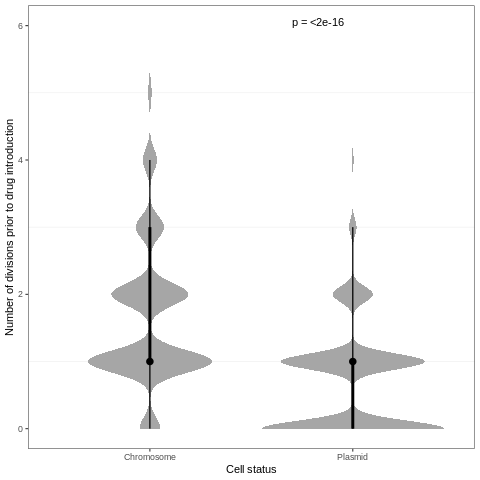

In [43]:

%%R
figure_to_save <- lineages_processed_1_df %>% 
  filter(time <= antibiotic_start_time) %>% 
  group_by(experiment_id, id) %>% 
  dplyr::summarize(
    n_divisions = sum(division),
    
  ) %>% 
  ggplot(aes(x = experiment_id, y = n_divisions)) +
  stat_eye(position = "dodge") +
  stat_compare_means(
    label = "p.format",
    method = "t.test",
    #ref.group = "Survived",
    label.x.npc = 0.75,
    hide.ns = TRUE
  ) +
  theme(
    panel.grid.major = element_blank(),
    legend.position = "none"
  ) +
  labs(
    x = "Cell status",
    y = "Number of divisions prior to drug introduction",
    fill = "Cell status"
  ) +
 # coord_flip() +
  NULL


figure_to_save



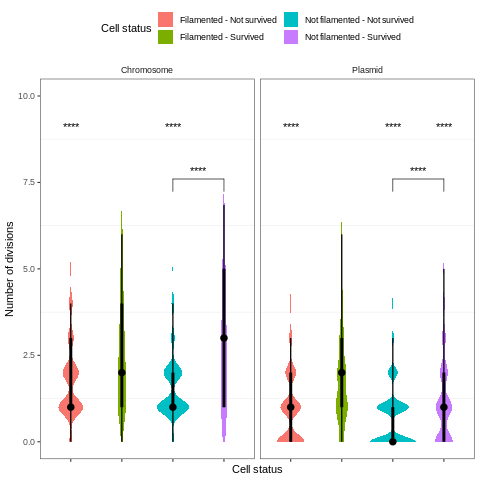

In [44]:
%%R
p_number_divisions <-cells_df %>% 
  ggplot(aes(x = cell_status, y = n_divisions, fill = cell_status)) +
  stat_eye(position = "dodge") +
  stat_compare_means(
    label = "p.signif",
    method = "t.test",
    ref.group = "Filamented - Survived",
    label.y.npc = 0.75,
    hide.ns = TRUE
  ) +
  stat_compare_means(
    method = "t.test",
    comparisons = list(c("Not filamented - Survived", "Not filamented - Not survived")),
    label = "p.signif",
    label.y = 7,
    hide.ns = TRUE
  ) +
  facet_grid(. ~ experiment_id) +
  coord_cartesian(ylim = c(0, 10)) +
  guides(
    fill = guide_legend(ncol = 2)
  ) +
  theme(
    panel.grid.major = element_blank(),
    axis.text.x = element_blank()
  ) +
  labs(
    x = "Cell status",
    y = "Number of divisions",
    fill = "Cell status"
  ) +
  NULL

p_number_divisions

## Plotting Figure S7

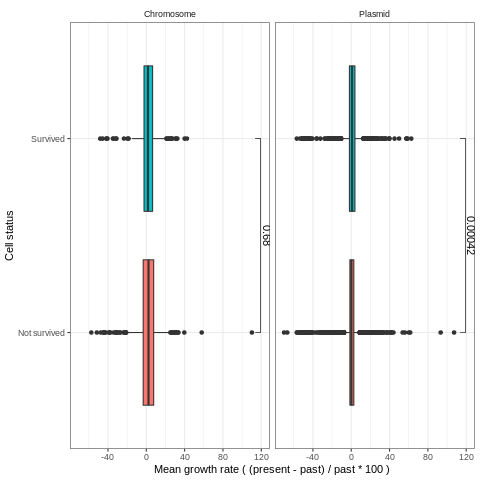

In [33]:
%%R
theme_set(theme_bw() +theme(legend.position = "top",strip.background = element_blank() ))

elongation_rates_dt <- lineages_processed_1_df %>% 
  select(experiment_id,
         id,
         survived,
         length,
         time,
         antibiotic_start_time,
         time_last
  ) %>% 
  filter(time <= time_last, time < antibiotic_start_time) %>% 
  arrange(experiment_id
          , id
          , time
  ) %>% 
  group_by(experiment_id,
           id,
           survived
  ) %>% 
  mutate(
    growth_rate = (length - lag(length)) / lag(length) * 100
  ) %>% 
  dplyr::summarize(
    mean_growth_rate = mean(growth_rate, na.rm = TRUE),
    .groups = "drop"
  ) %>% 
  ggplot(aes(x = survived, y = mean_growth_rate, fill = survived)) +
  geom_boxplot() +
  ggpubr::stat_compare_means(
    method = "t.test",
    comparisons = list(c("Survived", "Not survived"))
  ) +
  facet_grid(. ~ experiment_id) +
  coord_flip() +
  labs(
    x = "Cell status",
    y = "Mean growth rate ( (present - past) / past * 100 )"
  ) +
  theme(legend.position = "none") +
  NULL

elongation_rates_dt


## Plotting Figure S8

In [ ]:
%%R





## Plotting Figure S9

In [ ]:
%%R





## Plotting Figure S10

In [ ]:
%%R
step <- 0.04
breaks <- seq(min(lineages_processed_1_df$gfp) - step, max(lineages_processed_1_df$gfp) + step, step)
hist_gfp_control_info <- hist(
  lineages_processed_1_df$gfp,
  breaks = breaks,
  plot = FALSE
)
p_survival_probability_gfp <- lineages_processed_1_df %>%
  filter(experiment_id == "Plasmid", survived == "Survived", time == time_first) %>%
  group_by(filamented_id) %>%
  dplyr::summarize(
    counts = list(hist(gfp, plot = FALSE, breaks = breaks)$counts)
  ) %>%
  unnest(counts) %>%
  mutate(
    mids = rep(hist_gfp_control_info$mids, 2),
    control_counts = rep(hist_gfp_control_info$counts, times = 2),
    survival_probability = counts / control_counts
  ) %>%
  identity() %>%
  # filter(survival_probability != 0) %>%
  ggplot(aes(x = mids, y = survival_probability, color = filamented_id)) +
  geom_point() +
  geom_smooth(
    se = FALSE,
    size = 0.5,
    linetype = "dashed"
  ) +
  scale_x_continuous() +
  scale_y_continuous(labels = scales::label_percent()) +
  scale_color_hue(direction = -1, h.start = 90) +
  labs(
    x = "Initial GFP",
    y = "Survival probability",
    color = "Cell status"
  )
p_survival_probability_gfp




In [ ]:
%%R
step <- 1
breaks <- seq(min(lineages_processed_1_df$length) - step, max(lineages_processed_1_df$length) + step, step)
hist_length_control_info <- hist(
  lineages_processed_1_df$length,
  breaks = breaks,
  plot = FALSE
)

survival_probability_length <- lineages_processed_1_df %>%
  filter(experiment_id == "Plasmid", survived == "Survived", time == time_first) %>%
  group_by(filamented_id) %>%
  dplyr::summarize(
    counts = list(hist(length, plot = FALSE, breaks = breaks)$counts)
  ) %>%
  unnest(counts) %>%
  mutate(
    mids = rep(hist_length_control_info$mids, 2),
    control_counts = rep(hist_length_control_info$counts, times = 2),
    survival_probability = counts / control_counts
  ) %>%
  identity()

p_survival_probability_length <- survival_probability_length %>%
  filter(survival_probability != 1) %>%
  ggplot(aes(x = mids, y = survival_probability, color = filamented_id)) +
  geom_point() +
  geom_smooth(
    se = FALSE,
    size = 0.5,
    linetype = "dashed"
  ) +
  scale_x_continuous() +
  scale_y_continuous(labels = scales::label_percent()) +
  scale_color_hue(direction = -1, h.start = 90) +
  labs(
    x = "Initial length",
    y = "Survival probability",
    color = "Cell status"
  ) +
  coord_cartesian(
    xlim = c(FALSE, 120),
    ylim = c(0, 0.1)
  )

p_survival_probability_length

## Plotting Figure S11


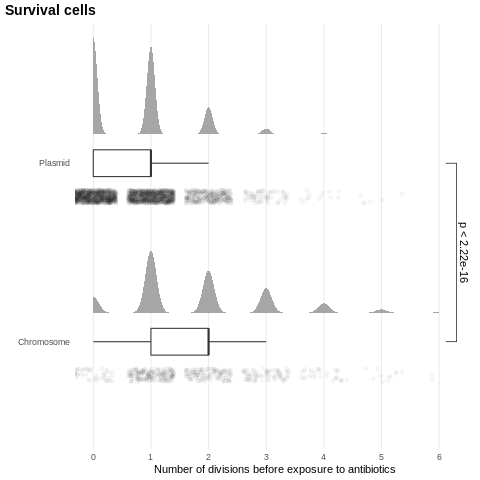

In [45]:
%%R
p_n_divisions <- lineages_processed_1_df |>
  filter(time <= antibiotic_start_time, survived == "Survived") |>
  group_by(experiment_id, id) |>
  dplyr::summarize(
    n_divisions = sum(division),
    .groups = "drop"
  ) |>
  ggplot(
    aes(
      x = experiment_id,
      y = n_divisions
    )
  ) +
  ggdist::stat_halfeye(
    adjust = 0.5,
    width = 0.6,
    .width = 0,
    justification = -0.3,
    point_colour = NA
  ) +
  geom_boxplot(
    width = 0.15,
    outlier.shape = NA
  ) +
  gghalves::geom_half_point(
    side = "l",
    range_scale = 0.2,
    alpha = 1 / 30
  ) +
  ggpubr::stat_compare_means(
    method = "t.test",
    comparisons = list(c("Plasmid", "Chromosome"))
  ) +
  scale_y_continuous(
    breaks = 0:6
  ) +
  coord_flip() +
  theme_minimal() +
  theme(
    panel.grid.major.y = element_blank(),
    panel.grid.minor.y = element_blank(),
    panel.grid.minor.x = element_blank(),
    legend.position = "none",
    plot.title.position = "plot",
    plot.title = element_text(
      face = "bold",
      size = 14,
      hjust = 0
    )
  ) +
  labs(
    x = "",
    y = "Number of divisions before exposure to antibiotics",
    title = "Survival cells"
  ) +
  NULL

p_n_divisions

# not used plots?

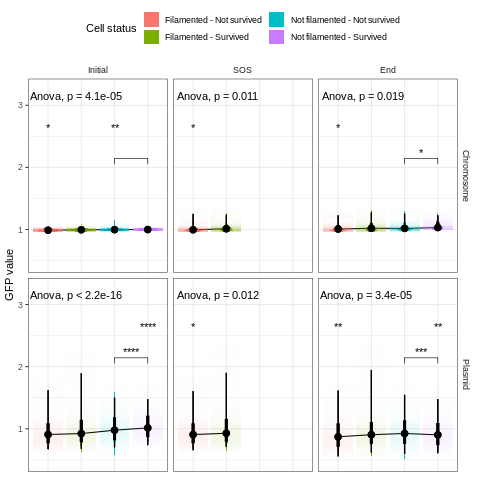

In [ ]:
%%R
p_temporal_gfp_distributution <- cells_df %>% 
  pivot_longer(
    cols = contains("gfp"),
    names_to = "metric",
    values_to = "value"
  ) %>% 
  parse_metrics_column(metric) %>% 
  filter(!is.na(value)) %>% 
  identity() %>% 
  ggplot(aes(x = cell_status, y = value, fill = cell_status)) +
  stat_eye() +
  stat_summary(fun=median, geom="line", aes(group=1))  +
  stat_compare_means(
    method = "t.test",
    comparisons = list(c("Not filamented - Survived", "Not filamented - Not survived")),
    label = "p.signif",
    label.y = c(2.0),
    hide.ns = TRUE
  ) +
  stat_compare_means(
    method = "anova",
    label.y.npc = 0.93
  ) + # Add global annova p-value
  stat_compare_means(
    label = "p.signif",
    method = "t.test",
    ref.group = "Filamented - Survived",
    hide.ns = TRUE,
    label.y.npc = 0.75
    ) +
  stat_gradientinterval(position = "dodge", fill_type = "segments") +
  facet_grid(experiment_id ~ metric) +
  guides(
    color = guide_legend(ncol = 2),
    fill = guide_legend(ncol = 2)
  ) +
  theme(
    axis.title.x = element_blank(),
    axis.text.x = element_blank(),
    axis.ticks.x = element_blank()
  ) +
  labs(
    fill = "Cell status",
    y = "GFP value"
  ) +
  NULL

p_temporal_gfp_distributution

In [ ]:
%%R
theme_set(theme_bw() +theme(legend.position = "top",strip.background = element_blank() ))

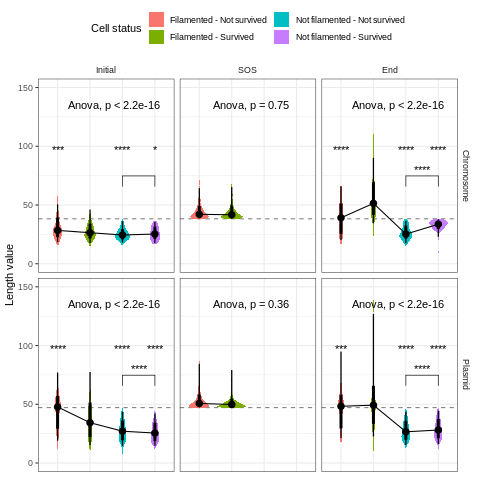

In [ ]:
%%R
p_temporal_length_distributution <- cells_df %>% 
  pivot_longer(
    cols = contains("length"),
    names_to = "metric",
    values_to = "value"
  ) %>% 
  parse_metrics_column(metric) %>% 
  filter(!is.na(value)) %>% 
  identity() %>% 
  ggplot(aes(x = cell_status, y = value, fill = cell_status)) +
  geom_hline(aes(yintercept = filamentation_threshold), linetype = "dashed", alpha = 1 / 2) +
  stat_eye() +
  stat_summary(fun=median, geom="line", aes(group=1))  +
  stat_compare_means(
    method = "t.test",
    comparisons = list(
      c("Not filamented - Survived", "Not filamented - Not survived")
    ),
    label = "p.signif",
    label.y = c(60),
    hide.ns = TRUE
  ) +
  stat_compare_means(
    method = "anova",
    label.y.npc = 0.43,
    label.x.npc = 0.3
  ) + # Add global annova p-value
  stat_compare_means(
    label = "p.signif",
    method = "t.test",
    ref.group = "Filamented - Survived",
    hide.ns = TRUE,
    label.y.npc = 0.3
  ) +
  #stat_gradientinterval(position = "dodge", fill_type = "segments") +
  facet_grid(experiment_id ~ metric) +
  coord_cartesian(ylim = c(0, 150)) +
  guides(
    color = guide_legend(ncol = 2),
    fill = guide_legend(ncol = 2)
  ) +
  theme(
    axis.title.x = element_blank(),
    axis.text.x = element_blank(),
    axis.ticks.x = element_blank()
  ) +
  labs(
    fill = "Cell status",
    y = "Length value"
  ) +
  NULL

p_temporal_length_distributution

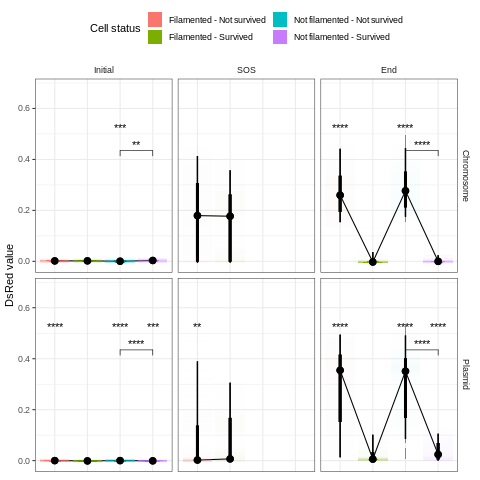

In [ ]:
%%R
p_temporal_dsred_distributution <- cells_df %>% 
  pivot_longer(
    cols = contains("ds_red"),
    names_to = "metric",
    values_to = "value"
  ) %>% 
  parse_metrics_column(metric) %>% 
  filter(!is.na(value)) %>% 
  identity() %>% 
  ggplot(aes(x = cell_status, y = value, fill = cell_status)) +
  stat_eye() +
  stat_summary(fun=median, geom="line", aes(group=1))  +
  stat_compare_means(
    method = "t.test",
    comparisons = list(c("Not filamented - Survived", "Not filamented - Not survived")),
    label = "p.signif",
    label.y = c(0.4),
    hide.ns = TRUE
  ) +
  # stat_compare_means(
  #   method = "anova",
  #   label.y.npc = 0.93
  # ) + # Add global annova p-value
  stat_compare_means(
    label = "p.signif",
    method = "t.test",
    ref.group = "Filamented - Survived",
    hide.ns = TRUE,
    label.y.npc = 0.75
    ) +
  stat_gradientinterval(position = "dodge", fill_type = "segments") +
  facet_grid(experiment_id ~ metric) +
  guides(
    color = guide_legend(ncol = 2),
    fill = guide_legend(ncol = 2)
  ) +
  theme(
    axis.title.x = element_blank(),
    axis.text.x = element_blank(),
    axis.ticks.x = element_blank()
  ) +
  labs(
    fill = "Cell status",
    y = "DsRed value"
  ) +
  NULL

p_temporal_dsred_distributution

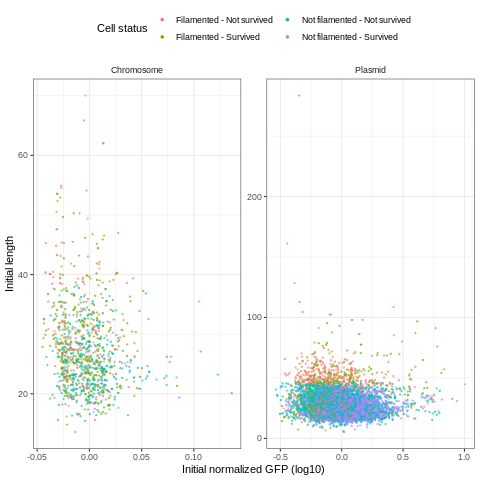

In [ ]:
%%R
p_initial_values <- cells_df %>% 
  ggplot(aes(x = log(gfp_first), y = length_first, color = cell_status)) +
  geom_point(alpha = 1/2, size = 0.5) +
  facet_wrap(. ~ experiment_id, scales = "free") +
  guides(
    color = guide_legend(ncol = 2, override.aes = list(alpha = 1, size = 1)),
    fill = guide_legend(ncol = 2)
  ) +
  labs(
    x = "Initial normalized GFP (log10)",
    y = "Initial length",
    color = "Cell status"
  ) +
  NULL

p_initial_values

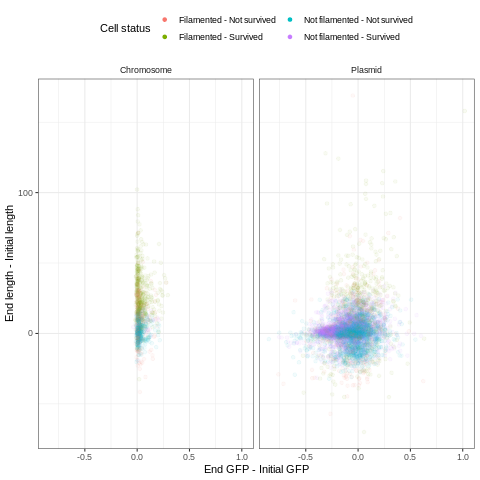

In [ ]:
%%R
p_metric_differences <- cells_df %>% 
  ggplot(aes(x = log(gfp_last) - log(gfp_first), y = length_last - length_first, color = cell_status)) +
  geom_point(alpha = 1/20) +
  facet_grid(~experiment_id) +
  guides(
    color = guide_legend(ncol = 2, override.aes = list(alpha = 1)),
    fill = guide_legend(ncol = 2)
  ) +
  labs(
    x = "End GFP - Initial GFP",
    y = "End length - Initial length",
    color = "Cell status"
  ) +
  NULL

p_metric_differences

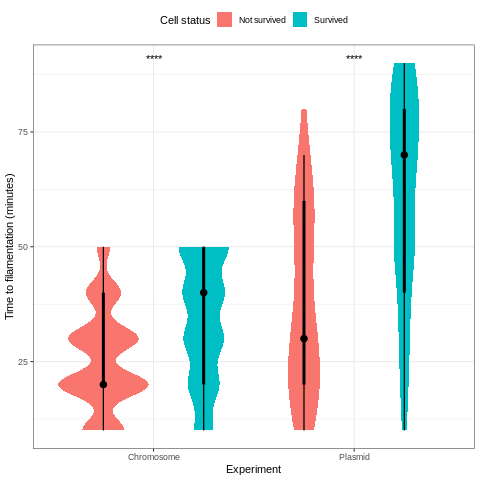

In [34]:
%%R
p_time_to_filamentation_filtered <- cells_df %>% 
  filter(
    filamented_id == "Filamented",
    time_sos > antibiotic_start_time
  ) %>% 
  mutate(
    time_to_sos = time_sos - antibiotic_start_time,
  ) %>%
  ggplot(aes( x = experiment_id, y = time_to_sos, fill = survived)) +
  stat_eye(position = "dodge") +
  stat_compare_means(
    label = "p.signif"
  ) +
  labs(
    x = "Experiment",
    y = "Time to filamentation (minutes)",
    fill = "Cell status"
  )

p_time_to_filamentation_filtered

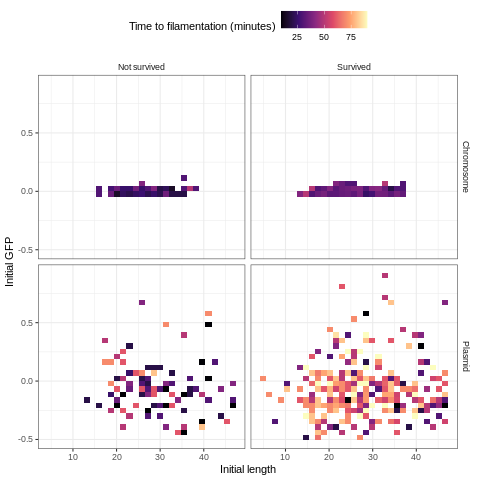

In [35]:
%%R
p_initial_values_with_time <- cells_df %>% 
  filter(
    filamented_id == "Filamented",
    time_sos > antibiotic_start_time
  ) %>% 
  mutate(time_to_sos = time_sos - antibiotic_start_time) %>%
  ggplot(aes(x = length_first, y = log(gfp_first), z = time_to_sos)) +
  stat_summary_2d() +
  facet_grid(experiment_id ~ survived) +
  scale_fill_viridis_c(option = "magma") +
  labs(
    x = "Initial length",
    y = "Initial GFP",
    fill = "Time to filamentation (minutes)"
  ) +
  NULL

p_initial_values_with_time

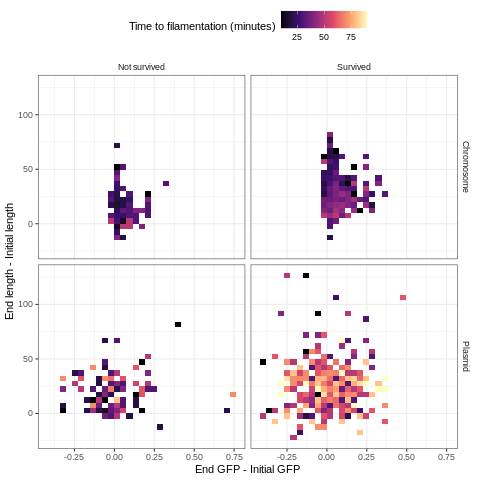

In [36]:
%%R
p_metric_differences_with_time <- cells_df %>% 
  filter(
    filamented_id == "Filamented",
    time_sos > antibiotic_start_time
  ) %>% 
  mutate(
    time_to_sos = time_sos - antibiotic_start_time,
    diff_length = length_last - length_first,
    diff_gfp = gfp_last - gfp_first
  ) %>%
  ggplot(aes(x = diff_gfp, y = diff_length, z = time_to_sos)) +
  stat_summary_2d() +
  facet_grid(experiment_id ~ survived) +
  scale_fill_viridis_c(option = "magma") +
  labs(
    x = "End GFP - Initial GFP",
    y = "End length - Initial length",
    fill = "Time to filamentation (minutes)"
  ) +
  NULL

p_metric_differences_with_time

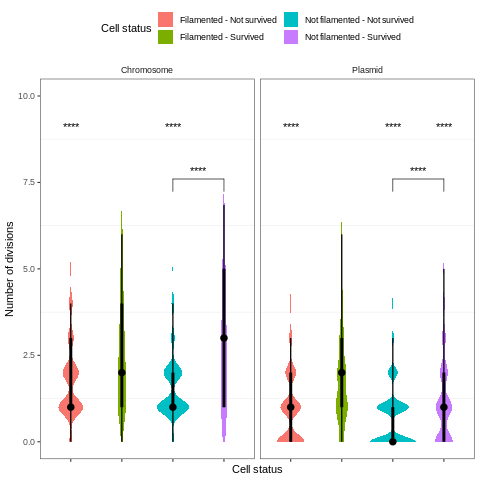

In [37]:
%%R
p_number_divisions <-cells_df %>% 
  ggplot(aes(x = cell_status, y = n_divisions, fill = cell_status)) +
  stat_eye(position = "dodge") +
  stat_compare_means(
    label = "p.signif",
    method = "t.test",
    ref.group = "Filamented - Survived",
    label.y.npc = 0.75,
    hide.ns = TRUE
  ) +
  stat_compare_means(
    method = "t.test",
    comparisons = list(c("Not filamented - Survived", "Not filamented - Not survived")),
    label = "p.signif",
    label.y = 7,
    hide.ns = TRUE
  ) +
  facet_grid(. ~ experiment_id) +
  coord_cartesian(ylim = c(0, 10)) +
  guides(
    fill = guide_legend(ncol = 2)
  ) +
  theme(
    panel.grid.major = element_blank(),
    axis.text.x = element_blank()
  ) +
  labs(
    x = "Cell status",
    y = "Number of divisions",
    fill = "Cell status"
  ) +
  NULL

p_number_divisions

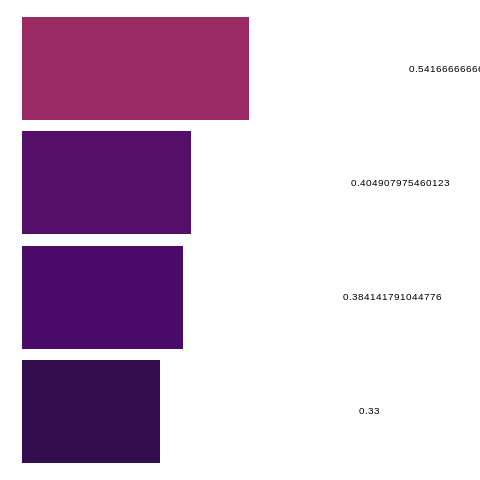

In [ ]:
%%R

counts_survived_by_gfp2 <- status_time_df %>%
  filter(experiment_id == "Plasmid") %>%
  mutate(
    gfp_first = gfp_first / max(gfp_first),
    gfp_first = cut(gfp_first, breaks = seq(0, 1, 0.25))
  ) %>%
  with_groups(
    gfp_first,
    ~ mutate(.x, n_at_gfp = filter(cur_data(), time == antibiotic_start_time) %>% nrow())
  ) %>%
  group_by(time, gfp_first) %>%
  summarise(
    percentage_alive = sum(cell_status_at_time != "Dead") / first(n_at_gfp),
    antibiotic_start_time = first(antibiotic_start_time),
    antibiotic_end_time = first(antibiotic_end_time),
    .groups = "drop"
  ) %>%
  identity()


quartile_p2 <- counts_survived_by_gfp2 %>%
  filter(time == antibiotic_end_time + 10) %>%
  ggplot(aes(x = percentage_alive, y = gfp_first, fill = percentage_alive)) +
  geom_bar(stat = "identity") +
  geom_text(aes(x=percentage_alive+.5, label=percentage_alive), 
            color="black", size=3.5)+
  scale_fill_viridis_c(
    option = "inferno",
    labels = scales::percent,
    limits = c(min(counts_survived_by_gfp$percentage_alive), max(counts_survived_by_gfp$percentage_alive))
  ) +
  theme_void() +
  theme(
    legend.position = "none"
  ) +
  NULL 

quartile_p2


In [ ]:
%%R
complete_time_dt_stats <- lineages_processed_1_df |>
  arrange(experiment_id, id, filamented_id, time) |>
  add_count(experiment_id, id, filamented_id, wt = division) |>
  filter(n != 0) |>
  group_by(experiment_id, id, filamented_id) |>
  dplyr::summarize(
    mean_dt_length = mean(lag(length), na.rm = TRUE),
    .groups = "drop"
  ) |>
  identity()


survival_time_dt_stats <- lineages_processed_1_df %>%
  add_count(experiment_id, id, filamented_id, wt = division) |>
  filter(
    n != 0,
    survived == "Survived",
    time <= antibiotic_start_time
  ) %>%
  arrange(experiment_id, id, filamented_id, time) |>
  group_by(experiment_id, id, filamented_id) |>
  dplyr::summarize(
    mean_dt_length = mean(lag(length), na.rm = TRUE),
    .groups = "drop"
  ) |>
  identity()

Rows: 23
Columns: 5
$ experiment_id        <chr> "Chromosome", "Chromosome", "Chromosome", "Chromo…
$ counts               <int> 1, 58, 265, 122, 30, 7, 4, 1, 0, 0, 0, 0, 0, 0, 0…
$ mids                 <dbl> 15.06289, 20.06289, 25.06289, 30.06289, 35.06289,…
$ control_counts       <int> 1, 106, 335, 229, 162, 80, 51, 21, 15, 10, 6, 8, …
$ survival_probability <dbl> 1.00000000, 0.54716981, 0.79104478, 0.53275109, 0…


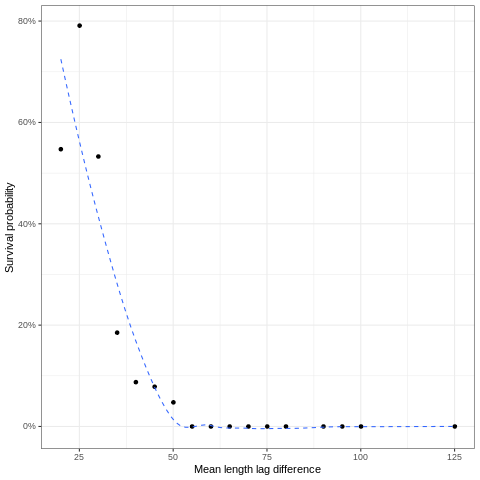

In [ ]:
%%R
chromosome_complete_dt_length <- complete_time_dt_stats |>
  filter(experiment_id == "Chromosome")

chromosome_survived_dt_length <- survival_time_dt_stats |>
  filter(experiment_id == "Chromosome")

step <- 5
breaks <- seq(
  min(chromosome_complete_dt_length$mean_dt_length) - step,
  max(chromosome_complete_dt_length$mean_dt_length) + step,
  step
)

chromosome_hist_dt_length_control_info <- hist(
  chromosome_complete_dt_length$mean_dt_length,
  breaks = breaks,
  plot = FALSE
)

chromosome_survival_probability_dt <- chromosome_survived_dt_length |>
  group_by(experiment_id) |>
  dplyr::summarize(
    counts = hist(mean_dt_length, plot = FALSE, breaks = breaks) |>
      pluck("counts") |>
      list()
  ) |>
  unnest(counts) |>
  mutate(
    mids = chromosome_hist_dt_length_control_info$mids,
    control_counts = chromosome_hist_dt_length_control_info$counts,
    survival_probability = counts / control_counts
  ) %>%
  glimpse()



p_survival_probability_chromosome_dt_length <- chromosome_survival_probability_dt %>%
  filter(survival_probability != 1) %>%
  ggplot(aes(x = mids, y = survival_probability)) +
  geom_point() +
  geom_smooth(
    se = FALSE,
    size = 0.5,
    linetype = "dashed"
  ) +
  scale_x_continuous() +
  scale_y_continuous(labels = scales::label_percent()) +
  labs(
    x = "Mean length lag difference",
    y = "Survival probability"
  )

p_survival_probability_chromosome_dt_length

Rows: 23
Columns: 5
$ experiment_id        <chr> "Plasmid", "Plasmid", "Plasmid", "Plasmid", "Plas…
$ counts               <int> 1, 28, 296, 554, 427, 225, 108, 65, 23, 10, 6, 1,…
$ mids                 <dbl> 7.991112, 12.991112, 17.991112, 22.991112, 27.991…
$ control_counts       <int> 1, 30, 396, 931, 813, 598, 302, 152, 59, 29, 19, …
$ survival_probability <dbl> 1.00000000, 0.93333333, 0.74747475, 0.59505908, 0…


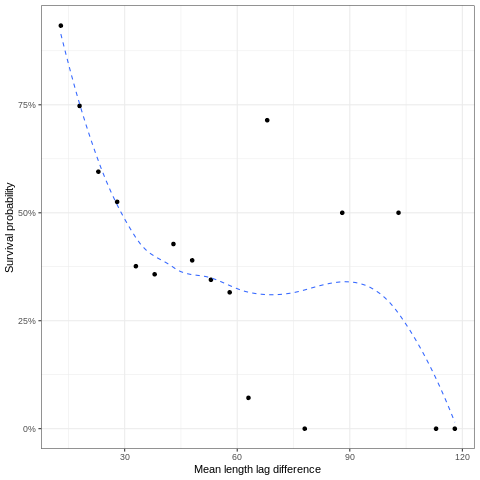

In [ ]:
%%R
plasmid_complete_dt_length <- complete_time_dt_stats |>
  filter(experiment_id == "Plasmid")

plasmid_survived_dt_length <- survival_time_dt_stats |>
  filter(experiment_id == "Plasmid")

step <- 5
breaks <- seq(
  min(plasmid_complete_dt_length$mean_dt_length) - step,
  max(plasmid_complete_dt_length$mean_dt_length) + step,
  step
)

plasmid_hist_dt_length_control_info <- hist(
  plasmid_complete_dt_length$mean_dt_length,
  breaks = breaks,
  plot = FALSE
)

plasmid_survival_probability_dt <- plasmid_survived_dt_length |>
  group_by(experiment_id) |>
  dplyr::summarize(
    counts = hist(mean_dt_length, plot = FALSE, breaks = breaks) |>
      pluck("counts") |>
      list()
  ) |>
  unnest(counts) |>
  mutate(
    mids = plasmid_hist_dt_length_control_info$mids,
    control_counts = plasmid_hist_dt_length_control_info$counts,
    survival_probability = counts / control_counts
  ) %>%
  glimpse()

p_survival_probability_plasmid_dt_length <- plasmid_survival_probability_dt %>%
  filter(survival_probability != 1) %>%
  ggplot(aes(x = mids, y = survival_probability)) +
  geom_point() +
  geom_smooth(
    se = FALSE,
    size = 0.5,
    linetype = "dashed"
  ) +
  scale_x_continuous() +
  scale_y_continuous(labels = scales::label_percent()) +
  labs(
    x = "Mean length lag difference",
    y = "Survival probability"
  )

p_survival_probability_plasmid_dt_length

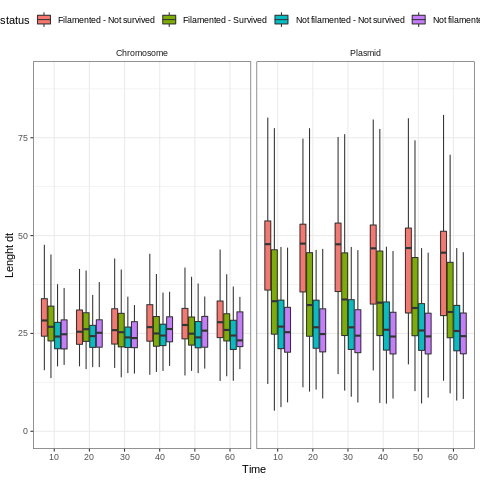

In [ ]:
%%R
lineages_processed_1_df |>
  group_by(experiment_id, id, cell_status, antibiotic_start_time) |>
  dplyr::summarize(
    time = time,
    dt_length = lag(length, n = 1),
    .groups = "drop"
  ) |>
  drop_na() |>
  filter(time <= antibiotic_start_time) |>
  ggplot(aes(x = factor(time), y = dt_length, fill = cell_status)) +
  geom_boxplot(outlier.shape = NA) +
  facet_grid(~experiment_id) +
  coord_cartesian(ylim = c(0, 90)) +
  labs(
    x = "Time",
    y = "Lenght dt",
    fill = "Cell status"
  )

In [ ]:
%%R
lineages_processed_1_df %>% 
  select(experiment_id,
         id,
         survived,
         length,
         time,
         antibiotic_start_time,
         time_last
  ) %>% 
  filter(time <= time_last, time < antibiotic_start_time) %>%
  arrange(experiment_id
          , id
          , time
  ) %>% 
  group_by(experiment_id,
           id,
           survived
  ) %>% 
  mutate(
    growth_rate = (length - lag(length)) / lag(length) * 100
  ) %>% 
  dplyr::summarize(
    mean_growth_rate = mean(growth_rate, na.rm = TRUE),
    .groups = "drop"
  ) %>% 
  drop_na() %>% 
  group_by(
    experiment_id,
    survived
  ) %>% 
  dplyr::summarise(
    what = 'Mean growth rate',
    min = min(mean_growth_rate),
    median = median(mean_growth_rate),
    mean = mean(mean_growth_rate),
    max = max(mean_growth_rate),
    std = sd(mean_growth_rate)
  )


`summarise()` has grouped output by 'experiment_id'. You can override using the
`.groups` argument.
# A tibble: 4 × 8
# Groups:   experiment_id [2]
  experiment_id survived     what               min median   mean   max   std
  <chr>         <fct>        <chr>            <dbl>  <dbl>  <dbl> <dbl> <dbl>
1 Chromosome    Not survived Mean growth rate -57.4  2.32   1.68  110.  13.9 
2 Chromosome    Survived     Mean growth rate -48.1  1.73   2.00   42.4  9.93
3 Plasmid       Not survived Mean growth rate -70.0  0.155 -0.423 107.  11.4 
4 Plasmid       Survived     Mean growth rate -56.8  0.868  0.568  62.7  9.46


`summarise()` has grouped output by 'experiment_id'. You can override using the
`.groups` argument.


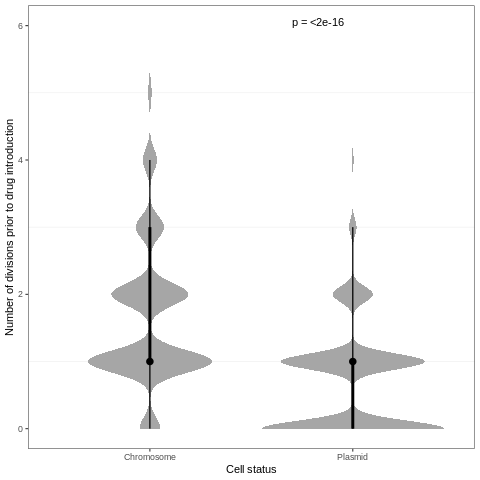

In [ ]:
%%R
figure_to_save <- lineages_processed_1_df %>% 
  filter(time <= antibiotic_start_time) %>% 
  group_by(experiment_id, id) %>% 
  dplyr::summarize(
    n_divisions = sum(division)
  ) %>% 
  ggplot(aes(x = experiment_id, y = n_divisions)) +
  stat_eye(position = "dodge") +
  stat_compare_means(
    label = "p.format",
    method = "t.test",
    #ref.group = "Survived",
    label.x.npc = 0.75,
    hide.ns = TRUE
  ) +
  theme(
    panel.grid.major = element_blank(),
    legend.position = "none"
  ) +
  labs(
    x = "Cell status",
    y = "Number of divisions prior to drug introduction",
    fill = "Cell status"
  ) +
 # coord_flip() +
  NULL


figure_to_save

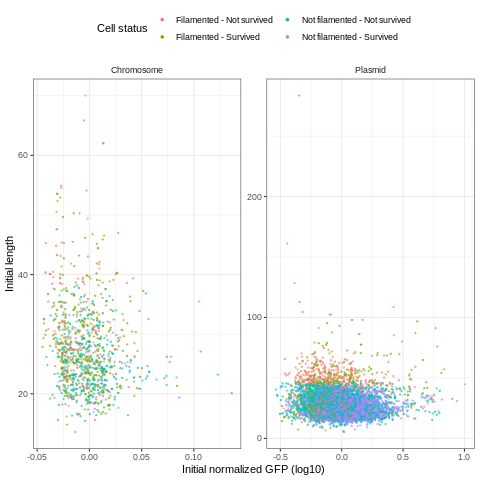

In [ ]:
%%R
p_initial_values <- cells_df %>% 
  ggplot(aes(x = log(gfp_first), y = length_first, color = cell_status)) +
  geom_point(alpha = 1/2, size = 0.5) +
  facet_wrap(. ~ experiment_id, scales = "free") +
  guides(
    color = guide_legend(ncol = 2, override.aes = list(alpha = 1, size = 1)),
    fill = guide_legend(ncol = 2)
  ) +
  labs(
    x = "Initial normalized GFP (log10)",
    y = "Initial length",
    color = "Cell status"
  ) +
  NULL

p_initial_values

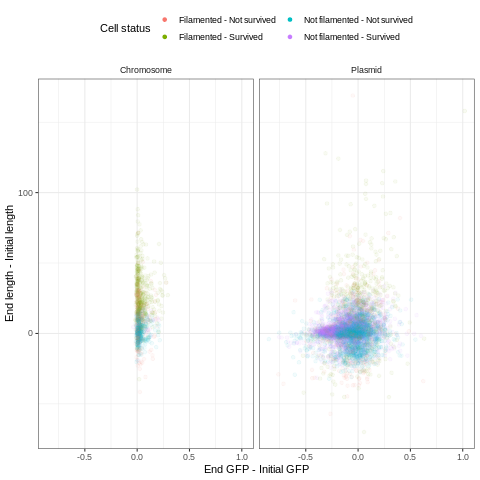

In [ ]:
%%R
p_metric_differences <- cells_df %>% 
  ggplot(aes(x = log(gfp_last) - log(gfp_first), y = length_last - length_first, color = cell_status)) +
  geom_point(alpha = 1/20) +
  facet_grid(~experiment_id) +
  guides(
    color = guide_legend(ncol = 2, override.aes = list(alpha = 1)),
    fill = guide_legend(ncol = 2)
  ) +
  labs(
    x = "End GFP - Initial GFP",
    y = "End length - Initial length",
    color = "Cell status"
  ) +
  NULL

p_metric_differences

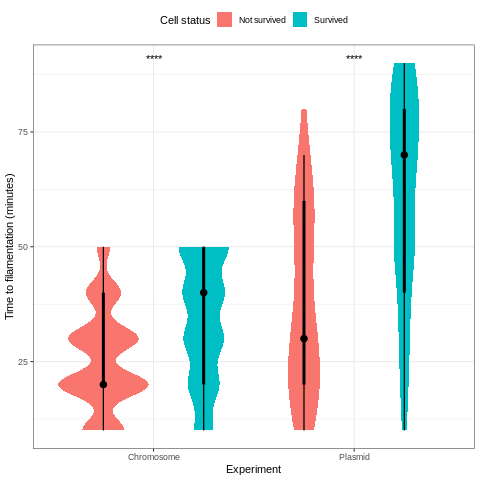

In [ ]:
%%R
p_time_to_filamentation_filtered <- cells_df %>% 
  filter(
    filamented_id == "Filamented",
    time_sos > antibiotic_start_time
  ) %>% 
  mutate(
    time_to_sos = time_sos - antibiotic_start_time,
  ) %>%
  ggplot(aes( x = experiment_id, y = time_to_sos, fill = survived)) +
  stat_eye(position = "dodge") +
  stat_compare_means(
    label = "p.signif"
  ) +
  labs(
    x = "Experiment",
    y = "Time to filamentation (minutes)",
    fill = "Cell status"
  )

p_time_to_filamentation_filtered

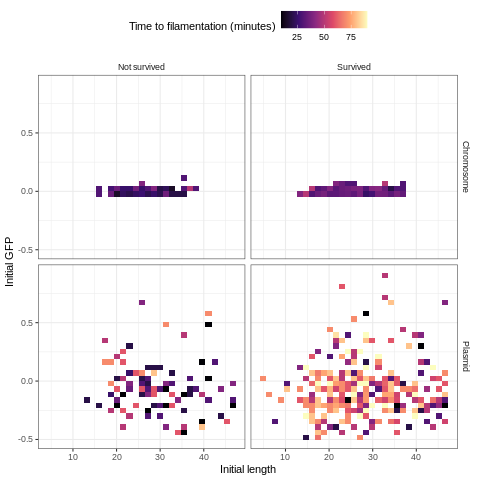

In [ ]:
%%R
p_initial_values_with_time <- cells_df %>% 
  filter(
    filamented_id == "Filamented",
    time_sos > antibiotic_start_time
  ) %>% 
  mutate(time_to_sos = time_sos - antibiotic_start_time) %>%
  ggplot(aes(x = length_first, y = log(gfp_first), z = time_to_sos)) +
  stat_summary_2d() +
  facet_grid(experiment_id ~ survived) +
  scale_fill_viridis_c(option = "magma") +
  labs(
    x = "Initial length",
    y = "Initial GFP",
    fill = "Time to filamentation (minutes)"
  ) +
  NULL

p_initial_values_with_time

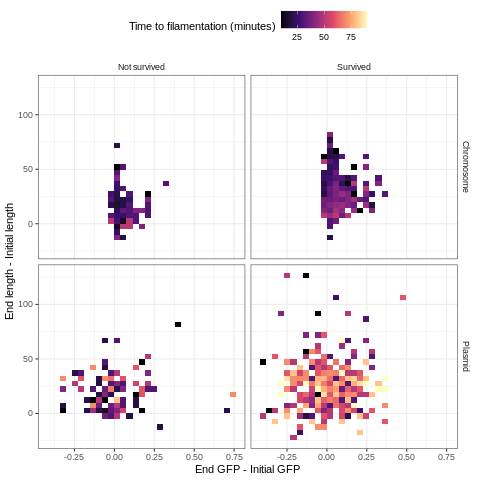

In [ ]:
%%R
p_metric_differences_with_time <- cells_df %>% 
  filter(
    filamented_id == "Filamented",
    time_sos > antibiotic_start_time
  ) %>% 
  mutate(
    time_to_sos = time_sos - antibiotic_start_time,
    diff_length = length_last - length_first,
    diff_gfp = gfp_last - gfp_first
  ) %>%
  ggplot(aes(x = diff_gfp, y = diff_length, z = time_to_sos)) +
  stat_summary_2d() +
  facet_grid(experiment_id ~ survived) +
  scale_fill_viridis_c(option = "magma") +
  labs(
    x = "End GFP - Initial GFP",
    y = "End length - Initial length",
    fill = "Time to filamentation (minutes)"
  ) +
  NULL

p_metric_differences_with_time

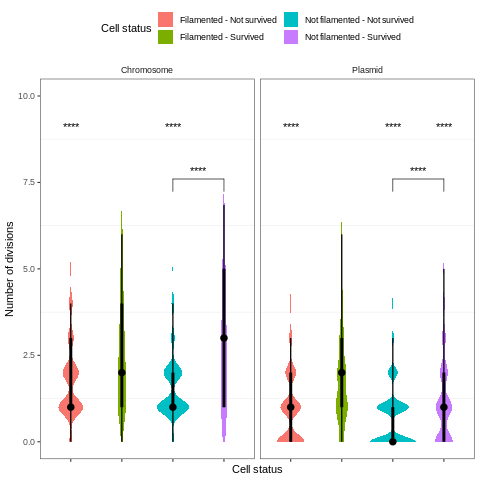

In [ ]:
%%R
p_number_divisions <-cells_df %>% 
  ggplot(aes(x = cell_status, y = n_divisions, fill = cell_status)) +
  stat_eye(position = "dodge") +
  stat_compare_means(
    label = "p.signif",
    method = "t.test",
    ref.group = "Filamented - Survived",
    label.y.npc = 0.75,
    hide.ns = TRUE
  ) +
  stat_compare_means(
    method = "t.test",
    comparisons = list(c("Not filamented - Survived", "Not filamented - Not survived")),
    label = "p.signif",
    label.y = 7,
    hide.ns = TRUE
  ) +
  facet_grid(. ~ experiment_id) +
  coord_cartesian(ylim = c(0, 10)) +
  guides(
    fill = guide_legend(ncol = 2)
  ) +
  theme(
    panel.grid.major = element_blank(),
    axis.text.x = element_blank()
  ) +
  labs(
    x = "Cell status",
    y = "Number of divisions",
    fill = "Cell status"
  ) +
  NULL

p_number_divisions

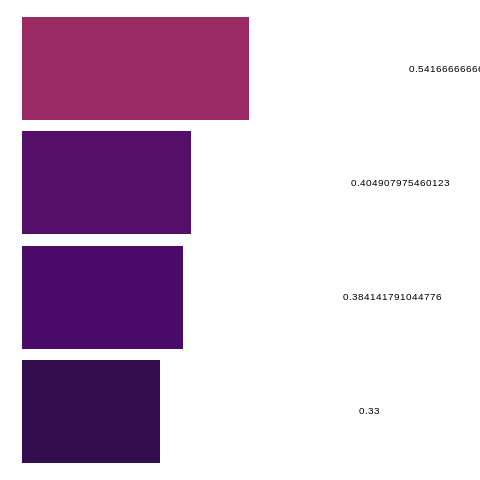

In [ ]:
%%R

counts_survived_by_gfp2 <- status_time_df %>%
  filter(experiment_id == "Plasmid") %>%
  mutate(
    gfp_first = gfp_first / max(gfp_first),
    gfp_first = cut(gfp_first, breaks = seq(0, 1, 0.25))
  ) %>%
  with_groups(
    gfp_first,
    ~ mutate(.x, n_at_gfp = filter(cur_data(), time == antibiotic_start_time) %>% nrow())
  ) %>%
  group_by(time, gfp_first) %>%
  summarise(
    percentage_alive = sum(cell_status_at_time != "Dead") / first(n_at_gfp),
    antibiotic_start_time = first(antibiotic_start_time),
    antibiotic_end_time = first(antibiotic_end_time),
    .groups = "drop"
  ) %>%
  identity()


quartile_p2 <- counts_survived_by_gfp2 %>%
  filter(time == antibiotic_end_time + 10) %>%
  ggplot(aes(x = percentage_alive, y = gfp_first, fill = percentage_alive)) +
  geom_bar(stat = "identity") +
  geom_text(aes(x=percentage_alive+.5, label=percentage_alive), 
            color="black", size=3.5)+
  scale_fill_viridis_c(
    option = "inferno",
    labels = scales::percent,
    limits = c(min(counts_survived_by_gfp$percentage_alive), max(counts_survived_by_gfp$percentage_alive))
  ) +
  theme_void() +
  theme(
    legend.position = "none"
  ) +
  NULL 

quartile_p2


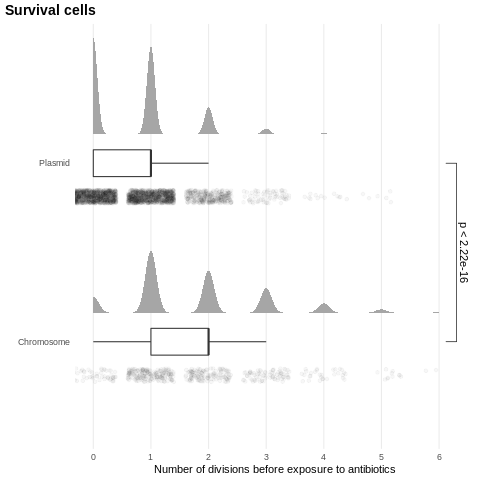

In [ ]:
%%R
complete_time_dt_stats <- lineages_processed_1_df |>
  arrange(experiment_id, id, filamented_id, time) |>
  add_count(experiment_id, id, filamented_id, wt = division) |>
  filter(n != 0) |>
  group_by(experiment_id, id, filamented_id) |>
  dplyr::summarize(
    mean_dt_length = mean(lag(length), na.rm = TRUE),
    .groups = "drop"
  ) |>
  identity()


survival_time_dt_stats <- lineages_processed_1_df %>%
  add_count(experiment_id, id, filamented_id, wt = division) |>
  filter(
    n != 0,
    survived == "Survived",
    time <= antibiotic_start_time
  ) %>%
  arrange(experiment_id, id, filamented_id, time) |>
  group_by(experiment_id, id, filamented_id) |>
  dplyr::summarize(
    mean_dt_length = mean(lag(length), na.rm = TRUE),
    .groups = "drop"
  ) |>
  identity()

Rows: 23
Columns: 5
$ experiment_id        <chr> "Chromosome", "Chromosome", "Chromosome", "Chromo…
$ counts               <int> 1, 58, 265, 122, 30, 7, 4, 1, 0, 0, 0, 0, 0, 0, 0…
$ mids                 <dbl> 15.06289, 20.06289, 25.06289, 30.06289, 35.06289,…
$ control_counts       <int> 1, 106, 335, 229, 162, 80, 51, 21, 15, 10, 6, 8, …
$ survival_probability <dbl> 1.00000000, 0.54716981, 0.79104478, 0.53275109, 0…


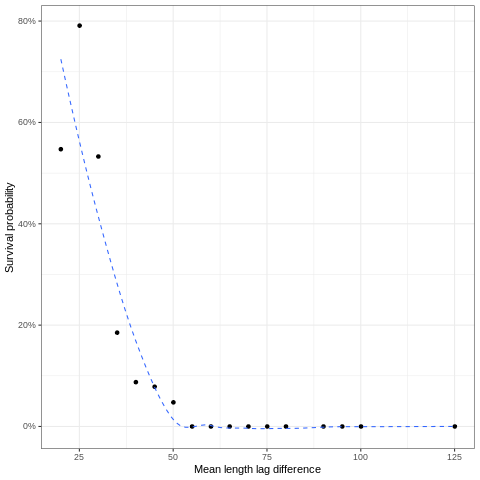

In [ ]:
%%R
chromosome_complete_dt_length <- complete_time_dt_stats |>
  filter(experiment_id == "Chromosome")

chromosome_survived_dt_length <- survival_time_dt_stats |>
  filter(experiment_id == "Chromosome")

step <- 5
breaks <- seq(
  min(chromosome_complete_dt_length$mean_dt_length) - step,
  max(chromosome_complete_dt_length$mean_dt_length) + step,
  step
)

chromosome_hist_dt_length_control_info <- hist(
  chromosome_complete_dt_length$mean_dt_length,
  breaks = breaks,
  plot = FALSE
)

chromosome_survival_probability_dt <- chromosome_survived_dt_length |>
  group_by(experiment_id) |>
  dplyr::summarize(
    counts = hist(mean_dt_length, plot = FALSE, breaks = breaks) |>
      pluck("counts") |>
      list()
  ) |>
  unnest(counts) |>
  mutate(
    mids = chromosome_hist_dt_length_control_info$mids,
    control_counts = chromosome_hist_dt_length_control_info$counts,
    survival_probability = counts / control_counts
  ) %>%
  glimpse()



p_survival_probability_chromosome_dt_length <- chromosome_survival_probability_dt %>%
  filter(survival_probability != 1) %>%
  ggplot(aes(x = mids, y = survival_probability)) +
  geom_point() +
  geom_smooth(
    se = FALSE,
    size = 0.5,
    linetype = "dashed"
  ) +
  scale_x_continuous() +
  scale_y_continuous(labels = scales::label_percent()) +
  labs(
    x = "Mean length lag difference",
    y = "Survival probability"
  )

p_survival_probability_chromosome_dt_length

Rows: 23
Columns: 5
$ experiment_id        <chr> "Plasmid", "Plasmid", "Plasmid", "Plasmid", "Plas…
$ counts               <int> 1, 28, 296, 554, 427, 225, 108, 65, 23, 10, 6, 1,…
$ mids                 <dbl> 7.991112, 12.991112, 17.991112, 22.991112, 27.991…
$ control_counts       <int> 1, 30, 396, 931, 813, 598, 302, 152, 59, 29, 19, …
$ survival_probability <dbl> 1.00000000, 0.93333333, 0.74747475, 0.59505908, 0…


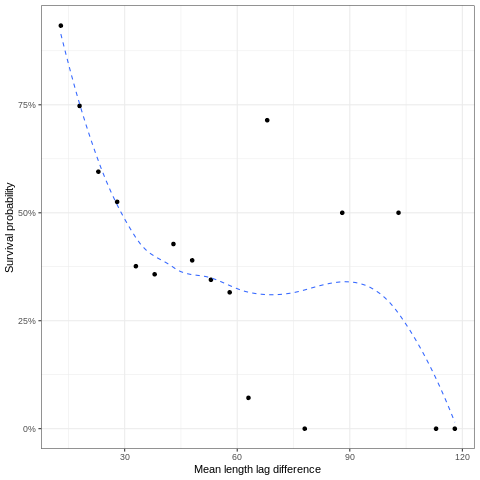

In [ ]:
%%R
plasmid_complete_dt_length <- complete_time_dt_stats |>
  filter(experiment_id == "Plasmid")

plasmid_survived_dt_length <- survival_time_dt_stats |>
  filter(experiment_id == "Plasmid")

step <- 5
breaks <- seq(
  min(plasmid_complete_dt_length$mean_dt_length) - step,
  max(plasmid_complete_dt_length$mean_dt_length) + step,
  step
)

plasmid_hist_dt_length_control_info <- hist(
  plasmid_complete_dt_length$mean_dt_length,
  breaks = breaks,
  plot = FALSE
)

plasmid_survival_probability_dt <- plasmid_survived_dt_length |>
  group_by(experiment_id) |>
  dplyr::summarize(
    counts = hist(mean_dt_length, plot = FALSE, breaks = breaks) |>
      pluck("counts") |>
      list()
  ) |>
  unnest(counts) |>
  mutate(
    mids = plasmid_hist_dt_length_control_info$mids,
    control_counts = plasmid_hist_dt_length_control_info$counts,
    survival_probability = counts / control_counts
  ) %>%
  glimpse()

p_survival_probability_plasmid_dt_length <- plasmid_survival_probability_dt %>%
  filter(survival_probability != 1) %>%
  ggplot(aes(x = mids, y = survival_probability)) +
  geom_point() +
  geom_smooth(
    se = FALSE,
    size = 0.5,
    linetype = "dashed"
  ) +
  scale_x_continuous() +
  scale_y_continuous(labels = scales::label_percent()) +
  labs(
    x = "Mean length lag difference",
    y = "Survival probability"
  )

p_survival_probability_plasmid_dt_length

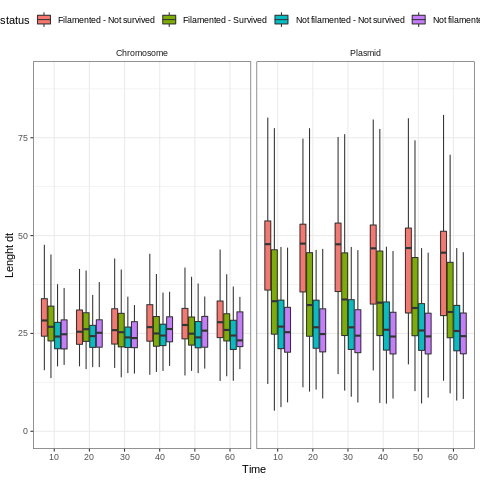

In [ ]:
%%R
lineages_processed_1_df |>
  group_by(experiment_id, id, cell_status, antibiotic_start_time) |>
  dplyr::summarize(
    time = time,
    dt_length = lag(length, n = 1),
    .groups = "drop"
  ) |>
  drop_na() |>
  filter(time <= antibiotic_start_time) |>
  ggplot(aes(x = factor(time), y = dt_length, fill = cell_status)) +
  geom_boxplot(outlier.shape = NA) +
  facet_grid(~experiment_id) +
  coord_cartesian(ylim = c(0, 90)) +
  labs(
    x = "Time",
    y = "Lenght dt",
    fill = "Cell status"
  )

In [ ]:
%%R
lineages_processed_1_df %>% 
  select(experiment_id,
         id,
         survived,
         length,
         time,
         antibiotic_start_time,
         time_last
  ) %>% 
  filter(time <= time_last, time < antibiotic_start_time) %>%
  arrange(experiment_id
          , id
          , time
  ) %>% 
  group_by(experiment_id,
           id,
           survived
  ) %>% 
  mutate(
    growth_rate = (length - lag(length)) / lag(length) * 100
  ) %>% 
  dplyr::summarize(
    mean_growth_rate = mean(growth_rate, na.rm = TRUE),
    .groups = "drop"
  ) %>% 
  drop_na() %>% 
  group_by(
    experiment_id,
    survived
  ) %>% 
  dplyr::summarise(
    what = 'Mean growth rate',
    min = min(mean_growth_rate),
    median = median(mean_growth_rate),
    mean = mean(mean_growth_rate),
    max = max(mean_growth_rate),
    std = sd(mean_growth_rate)
  )


`summarise()` has grouped output by 'experiment_id'. You can override using the
`.groups` argument.
# A tibble: 4 × 8
# Groups:   experiment_id [2]
  experiment_id survived     what               min median   mean   max   std
  <chr>         <fct>        <chr>            <dbl>  <dbl>  <dbl> <dbl> <dbl>
1 Chromosome    Not survived Mean growth rate -57.4  2.32   1.68  110.  13.9 
2 Chromosome    Survived     Mean growth rate -48.1  1.73   2.00   42.4  9.93
3 Plasmid       Not survived Mean growth rate -70.0  0.155 -0.423 107.  11.4 
4 Plasmid       Survived     Mean growth rate -56.8  0.868  0.568  62.7  9.46


`summarise()` has grouped output by 'experiment_id'. You can override using the
`.groups` argument.


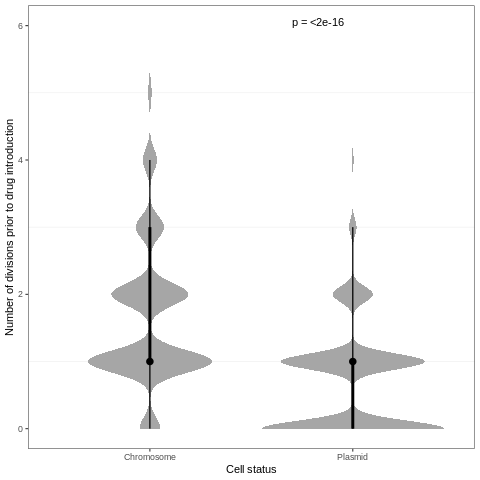

In [ ]:
%%R
figure_to_save <- lineages_processed_1_df %>% 
  filter(time <= antibiotic_start_time) %>% 
  group_by(experiment_id, id) %>% 
  dplyr::summarize(
    n_divisions = sum(division)
  ) %>% 
  ggplot(aes(x = experiment_id, y = n_divisions)) +
  stat_eye(position = "dodge") +
  stat_compare_means(
    label = "p.format",
    method = "t.test",
    #ref.group = "Survived",
    label.x.npc = 0.75,
    hide.ns = TRUE
  ) +
  theme(
    panel.grid.major = element_blank(),
    legend.position = "none"
  ) +
  labs(
    x = "Cell status",
    y = "Number of divisions prior to drug introduction",
    fill = "Cell status"
  ) +
 # coord_flip() +
  NULL


figure_to_save